# PREVENÇÃO DE INUNDAÇÕES EM ANGOLA - GOOGLE COLAB

In [1]:
#@title 1. CONFIGURAÇÃO INICIAL DO COLAB
try:
    from google.colab import files
    IN_COLAB = True
    print(" Ambiente: Google Colab")
except ImportError:
    IN_COLAB = False
    print(" Ambiente: Local/VS Code")

 Ambiente: Google Colab


In [2]:
#@title 2. INSTALAÇÃO DE BIBLIOTECAS (Colab específico)
!pip install xgboost plotly scikit-plot imbalanced-learn -q
!pip install geopandas contextily folium -q  # Para mapas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 89.8 MB/s eta 0:00:00


In [3]:
#@title 3. IMPORTAR BIBLIOTECAS
import pandas as pd
import numpy as np
import logging
import sys
from datetime import datetime
import json
import pickle
import io
import warnings
warnings.filterwarnings('ignore')

# Configurar logging para Colab
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

# Tratamento de desbalanceamento
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Modelos avançados
import xgboost as xgb
from xgboost import XGBClassifier

# Visualização (otimizado para Colab)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Mapas interativos
import folium
from folium import plugins

# Configurações
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

logger.info(" Bibliotecas carregadas com sucesso!")


In [4]:
#@title 4. CARREGAMENTO DE DADOS NO COLAB
def carregar_dados_colab():
    """Carrega dados via upload no Colab"""
    logger.info(" Aguardando upload do arquivo CSV...")

    uploaded = files.upload()
    filename = list(uploaded.keys())[0]

    # Verificar tipo de arquivo
    if filename.endswith('.csv'):
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
    elif filename.endswith('.xlsx'):
        df = pd.read_excel(io.BytesIO(uploaded[filename]))
    else:
        raise ValueError("Formato não suportado. Use CSV ou Excel.")

    logger.info(f" Dataset '{filename}' carregado! Shape: {df.shape}")

    # Mostrar preview interativo
    print("\n PRÉ-VISUALIZAÇÃO DOS DADOS:")
    display(df.head())

    print(f"\n ESTATÍSTICAS BÁSICAS:")
    display(df.describe())

    return df

In [5]:
#@title 5. ANÁLISE EXPLORATÓRIA INTERATIVA
def analise_exploratoria_colab(df):
    """Análise exploratória com visualizações interativas"""

    print(" INICIANDO ANÁLISE EXPLORATÓRIA...")

    # 1. Distribuição do target
    fig = px.pie(df, names='flood', title='Distribuição de Inundações (Target)',
                 color='flood', color_discrete_map={0:'blue', 1:'red'})
    fig.show()

    # 2. Correlações
    plt.figure(figsize=(12, 8))
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    correlation_matrix = df[numeric_cols].corr()

    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', linewidths=0.5)
    plt.title('Mapa de Correlação - Variáveis Numéricas')
    plt.tight_layout()
    plt.show()

    # 3. Distribuição de features numéricas
    numeric_features = ['precipitacao_mm', 'temperatura_C', 'humidade_percent']

    fig = make_subplots(rows=2, cols=2, subplot_titles=numeric_features)

    for i, feature in enumerate(numeric_features):
        row = (i // 2) + 1
        col = (i % 2) + 1

        fig.add_trace(
            go.Histogram(x=df[feature], name=feature),
            row=row, col=col
        )

    fig.update_layout(height=600, title_text="Distribuição das Features Numéricas")
    fig.show()

    # 4. Boxplots por status de inundação
    fig = px.box(df, x='flood', y='precipitacao_mm',
                 title='Precipitação vs Inundação',
                 color='flood')
    fig.show()

In [6]:
#@title 6. ENGENHARIA DE FEATURES PARA ANGOLA
def criar_features_angola(df):
    """Cria features específicas para o contexto de Angola"""

    logger.info(" Criando features climáticas para Angola...")

    # Mapeamento de regiões climáticas
    REGIOES_CLIMATICAS = {
        'Litoral': ['Luanda', 'Benguela', 'Cabinda', 'Namibe', 'Zaire'],
        'Semi-Árido': ['Cunene', 'Namibe', 'Cuando Cubango'],
        'Planalto Central': ['Huambo', 'Bié', 'Huíla'],
        'Norte Úmido': ['Uíge', 'Malanje', 'Kwanza Norte']
    }

    def classificar_regiao(provincia):
        for regiao, provincias in REGIOES_CLIMATICAS.items():
            if provincia in provincias:
                return regiao
        return 'Outra'

    # Features baseadas em conhecimento de domínio
    df['regiao_climatica'] = df['provincia'].apply(classificar_regiao)

    # Estações climáticas de Angola
    def estacao_angola(mes):
        # Chuva: Out-Abr | Seca: Mai-Set
        if mes in [10, 11, 12, 1, 2, 3, 4]:
            return 'Chuvosa'
        else:
            return 'Seca'

    df['estacao'] = df['mes'].apply(estacao_angola)
    df['estacao_chuvosa'] = (df['mes'].isin([10, 11, 12, 1, 2, 3, 4])).astype(int)

    # Features de risco
    df['precipitacao_extrema'] = (df['precipitacao_mm'] > 150).astype(int)
    df['risco_composto'] = (df['precipitacao_mm'] * df['humidade_percent']) / 100

    # Interações climáticas
    df['temp_umidade_interaction'] = df['temperatura_C'] * df['humidade_percent']
    df['precipitacao_quadrado'] = df['precipitacao_mm'] ** 2

    # Indicadores de tendência
    if 'dia' in df.columns:
        df['final_de_semana'] = ((df['dia'] % 7) >= 5).astype(int)

    logger.info(f" Features criadas! Colunas: {list(df.columns)}")
    return df

In [7]:
#@title 7. MODELAGEM AVANÇADA
class SistemaPrevencaoInundacoes:
    """Sistema completo de prevenção de inundações"""

    def __init__(self):
        self.models = {}
        self.results = {}
        self.preprocessor = None
        self.feature_names = []

    def preparar_dados(self, df):
        """Prepara dados para modelagem"""

        # Definir features base
        features_base = [
            'precipitacao_mm', 'temperatura_C', 'humidade_percent',
            'vento_kmh', 'rad_solar_Wm2'
        ]

        # Features de engenharia
        features_engenharia = [
            'estacao_chuvosa', 'precipitacao_extrema', 'risco_composto',
            'temp_umidade_interaction', 'precipitacao_quadrado'
        ]

        # Combinar todas as features
        self.feature_names = features_base + features_engenharia

        # Garantir que todas as features existem
        features_finais = [f for f in self.feature_names if f in df.columns]

        X = df[features_finais]
        y = df['flood']

        logger.info(f" Features selecionadas: {features_finais}")
        logger.info(f" Distribuição do target: {y.value_counts().to_dict()}")

        return X, y, features_finais

    def criar_preprocessador(self, features):
        """Cria pipeline de pré-processamento"""

        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), features)
            ]
        )

        return self.preprocessor

    def treinar_modelos(self, X_train, y_train, features):
        """Treina múltiplos modelos com otimização"""

        # Calcular pesos para balanceamento
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        weight_dict = dict(zip(np.unique(y_train), class_weights))

        # Configuração dos modelos
        modelos_config = {
            'XGBoost': {
                'model': XGBClassifier(
                    random_state=RANDOM_STATE,
                    eval_metric='logloss',
                    use_label_encoder=False,
                    scale_pos_weight=weight_dict[1]/weight_dict[0]
                ),
                'params': {
                    'classifier__n_estimators': [100, 200, 300],
                    'classifier__max_depth': [3, 6, 9],
                    'classifier__learning_rate': [0.01, 0.1, 0.2]
                }
            },
            'Random Forest': {
                'model': RandomForestClassifier(random_state=RANDOM_STATE),
                'params': {
                    'classifier__n_estimators': [100, 200],
                    'classifier__max_depth': [10, 20, None],
                    'classifier__min_samples_split': [2, 5, 10]
                }
            },
            'Logistic Regression': {
                'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
                'params': {
                    'classifier__C': [0.1, 1, 10],
                    'classifier__class_weight': ['balanced', None]
                }
            }
        }

        # Treinar cada modelo
        for nome, config in modelos_config.items():
            logger.info(f" Treinando {nome}...")

            try:
                # Pipeline com SMOTE
                pipeline = ImbPipeline([
                    ('preprocessor', self.preprocessor),
                    ('smote', SMOTE(random_state=RANDOM_STATE)),
                    ('classifier', config['model'])
                ])

                # Busca de hiperparâmetros
                busca = RandomizedSearchCV(
                    pipeline, config['params'],
                    n_iter=10, cv=3, scoring='f1',
                    random_state=RANDOM_STATE, n_jobs=-1
                )

                busca.fit(X_train, y_train)
                self.models[nome] = busca.best_estimator_

                logger.info(f" {nome} treinado! Melhor F1: {busca.best_score_:.4f}")

            except Exception as e:
                logger.error(f" Erro em {nome}: {e}")

    def avaliar_modelos(self, X_test, y_test):
        """Avalia todos os modelos treinados"""

        resultados = {}

        for nome, modelo in self.models.items():
            logger.info(f" Avaliando {nome}...")

            # Previsões
            y_pred = modelo.predict(X_test)
            y_proba = modelo.predict_proba(X_test)[:, 1]

            # Métricas
            metrics = {
                'acuracia': accuracy_score(y_test, y_pred),
                'precisao': precision_score(y_test, y_pred, zero_division=0),
                'recall': recall_score(y_test, y_pred, zero_division=0),
                'f1': f1_score(y_test, y_pred, zero_division=0),
                'auc_roc': roc_auc_score(y_test, y_proba),
                'modelo': modelo,
                'previsoes': y_pred,
                'probabilidades': y_proba
            }

            # Matriz de confusão
            metrics['matriz_confusao'] = confusion_matrix(y_test, y_pred)

            resultados[nome] = metrics

            print(f"\n {nome}:")
            print(f"   F1-Score: {metrics['f1']:.4f}")
            print(f"   AUC-ROC: {metrics['auc_roc']:.4f}")
            print(f"   Precisão: {metrics['precisao']:.4f}")
            print(f"   Recall: {metrics['recall']:.4f}")

        self.results = resultados
        return resultados

    def visualizar_resultados(self, df, X_test, y_test):
        """Cria visualizações completas dos resultados"""

        if not self.results:
            logger.warning("Nenhum resultado para visualizar")
            return

        # 1. Comparação de modelos
        modelos = list(self.results.keys())
        f1_scores = [self.results[m]['f1'] for m in modelos]
        auc_scores = [self.results[m]['auc_roc'] for m in modelos]

        fig = go.Figure(data=[
            go.Bar(name='F1-Score', x=modelos, y=f1_scores),
            go.Bar(name='AUC-ROC', x=modelos, y=auc_scores)
        ])

        fig.update_layout(title='Comparação de Desempenho dos Modelos',
                         barmode='group')
        fig.show()

        # 2. Curvas ROC
        fig_roc = go.Figure()
        fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1],
                                   mode='lines',
                                   line=dict(dash='dash'),
                                   name='Linha Base'))

        for nome, resultado in self.results.items():
            fpr, tpr, _ = roc_curve(y_test, resultado['probabilidades'])
            auc_score = resultado['auc_roc']

            fig_roc.add_trace(go.Scatter(x=fpr, y=tpr,
                                       mode='lines',
                                       name=f'{nome} (AUC = {auc_score:.3f})'))

        fig_roc.update_layout(title='Curvas ROC - Comparação de Modelos',
                            xaxis_title='Taxa de Falsos Positivos',
                            yaxis_title='Taxa de Verdadeiros Positivos')
        fig_roc.show()

        # 3. Mapa de calor de correlações
        plt.figure(figsize=(10, 8))
        correlacoes = df[self.feature_names + ['flood']].corr()
        sns.heatmap(correlacoes, annot=True, cmap='coolwarm', center=0, fmt='.2f')
        plt.title('Correlação entre Features e Inundações')
        plt.tight_layout()
        plt.show()

In [8]:
#@title 8. MAPA INTERATIVO DE RISCO
def criar_mapa_risco(df, modelo, preprocessor, features):
    """Cria mapa interativo de risco de inundação"""

    logger.info(" Criando mapa de risco...")

    # Centro de Angola
    mapa = folium.Map(location=[-12.5, 18.5], zoom_start=6)

    # Adicionar pontos de dados
    for idx, row in df.iterrows():
        if pd.notna(row['latitude']) and pd.notna(row['longitude']):
            # Preparar features para predição
            X_pred = pd.DataFrame([row[features]])
            risco = modelo.predict_proba(X_pred)[0, 1]

            # Cor baseada no risco
            cor = 'red' if risco > 0.7 else 'orange' if risco > 0.4 else 'green'

            popup_text = f"""
            <b>Província:</b> {row.get('provincia', 'N/A')}<br>
            <b>Risco:</b> {risco:.1%}<br>
            <b>Precipitação:</b> {row.get('precipitacao_mm', 'N/A')}mm<br>
            <b>Inundação Real:</b> {row.get('flood', 'N/A')}
            """

            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=10,
                popup=folium.Popup(popup_text, max_width=300),
                color=cor,
                fill=True,
                fillColor=cor
            ).add_to(mapa)

    return mapa

In [9]:
#@title 9. FUNÇÃO PRINCIPAL
def main_colab():
    """Função principal"""

    print(" INICIANDO SISTEMA DE PREVENÇÃO DE INUNDAÇÕES ANGOLA")

    try:
        # 1. Carregar dados
        df = carregar_dados_colab()

        # 2. Análise exploratória
        analise_exploratoria_colab(df)

        # 3. Engenharia de features
        df = criar_features_angola(df)

        # 4. Sistema de modelagem
        sistema = SistemaPrevencaoInundacoes()
        X, y, features = sistema.preparar_dados(df)

        # 5. Split dos dados
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
        )

        # 6. Pré-processamento
        preprocessor = sistema.criar_preprocessador(features)

        # 7. Treinamento
        sistema.treinar_modelos(X_train, y_train, features)

        if not sistema.models:
            logger.error(" Nenhum modelo foi treinado com sucesso")
            return

        # 8. Avaliação
        resultados = sistema.avaliar_modelos(X_test, y_test)

        # 9. Visualizações
        sistema.visualizar_resultados(df, X_test, y_test)

        # 10. Mapa de risco com melhor modelo
        melhor_modelo_nome = max(resultados, key=lambda x: resultados[x]['f1'])
        melhor_modelo = resultados[melhor_modelo_nome]['modelo']

        print(f"\n MELHOR MODELO: {melhor_modelo_nome}")
        print(f" F1-Score: {resultados[melhor_modelo_nome]['f1']:.4f}")

        # 11. Salvar modelo
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        nome_arquivo = f"modelo_inundacoes_angola_{timestamp}.pkl"

        with open(nome_arquivo, 'wb') as f:
            pickle.dump({
                'modelo': melhor_modelo,
                'features': features,
                'preprocessor': preprocessor,
                'metricas': resultados[melhor_modelo_nome],
                'timestamp': timestamp
            }, f)

        print(f" Modelo salvo como: {nome_arquivo}")

        # 12. Mapa interativo (se coordenadas disponíveis)
        if all(col in df.columns for col in ['latitude', 'longitude']):
            mapa = criar_mapa_risco(df, melhor_modelo, preprocessor, features)
            display(mapa)

        print("\n SISTEMA CONCLUÍDO COM SUCESSO!")

    except Exception as e:
        logger.error(f" Erro no sistema: {e}")
        raise

 INICIANDO SISTEMA DE PREVENÇÃO DE INUNDAÇÕES ANGOLA


Saving dataset_angola_corrigido.csv to dataset_angola_corrigido.csv

 PRÉ-VISUALIZAÇÃO DOS DADOS:


,provincia,latitude,longitude,ano,mes,precipitacao_mm,temperatura_C,humidade_percent,vento_kmh,rad_solar_Wm2,flood
0,Cunene,-16.267329,15.786174,2023,2,165.359826,31.694854,95.000000,15.069739,155.583228,1
1,Moxico,-11.795744,19.953658,2024,2,89.315105,23.896548,72.240146,7.948676,213.198631,0
2,Huíla,-15.007802,13.791770,2024,12,255.308285,21.411325,95.000000,12.443690,100.000000,1
3,Uíge,-7.579430,14.989936,2023,12,250.983658,24.776341,95.000000,15.290180,100.000000,1
4,Huíla,-14.896114,13.737033,2025,1,135.744695,24.650775,85.992456,10.795585,145.164603,1



 ESTATÍSTICAS BÁSICAS:


,latitude,longitude,ano,mes,precipitacao_mm,temperatura_C,humidade_percent,vento_kmh,rad_solar_Wm2,flood
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,-11.465441,14.936303,2024.024000,6.58600,131.616108,27.383868,82.599486,12.051125,186.158365,0.662000
std,3.471105,2.231086,0.820225,3.52526,74.006279,3.161150,12.667549,3.771065,44.676679,0.473502
min,-16.524781,11.872873,2023.000000,1.00000,0.000000,19.412474,46.445525,5.000000,100.000000,0.000000
25%,-14.844588,13.354860,2023.000000,3.00000,74.022049,25.072857,73.646382,9.175943,155.751297,0.000000
50%,-12.453017,14.846941,2024.000000,7.00000,124.859335,27.398128,85.433870,12.087039,187.010731,1.000000
75%,-8.720042,15.767967,2025.000000,10.00000,184.276935,29.812422,95.000000,14.542174,219.808978,1.000000
max,-5.340206,20.200609,2025.000000,12.00000,372.689845,36.398288,95.000000,22.107730,311.221281,1.000000


 INICIANDO ANÁLISE EXPLORATÓRIA...


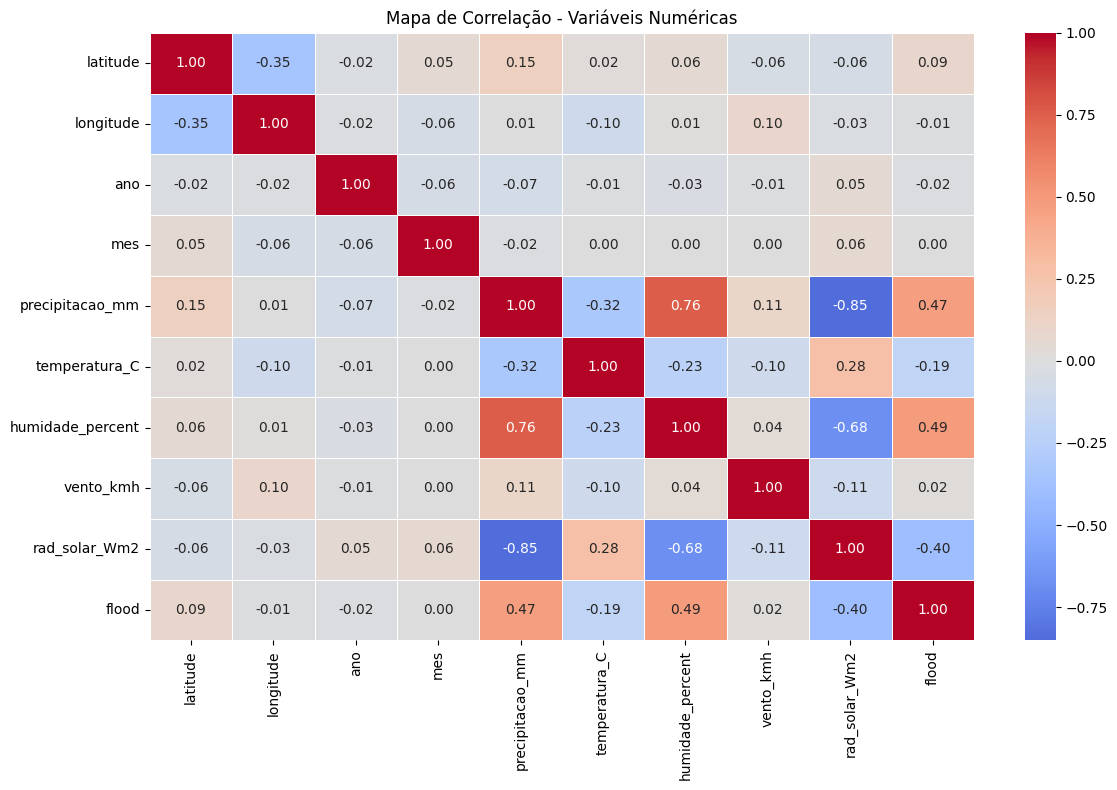


 XGBoost:
   F1-Score: 0.8000
   AUC-ROC: 0.8102
   Precisão: 0.8475
   Recall: 0.7576

 Random Forest:
   F1-Score: 0.8148
   AUC-ROC: 0.8244
   Precisão: 0.7971
   Recall: 0.8333

 Logistic Regression:
   F1-Score: 0.8217
   AUC-ROC: 0.8454
   Precisão: 0.8413
   Recall: 0.8030


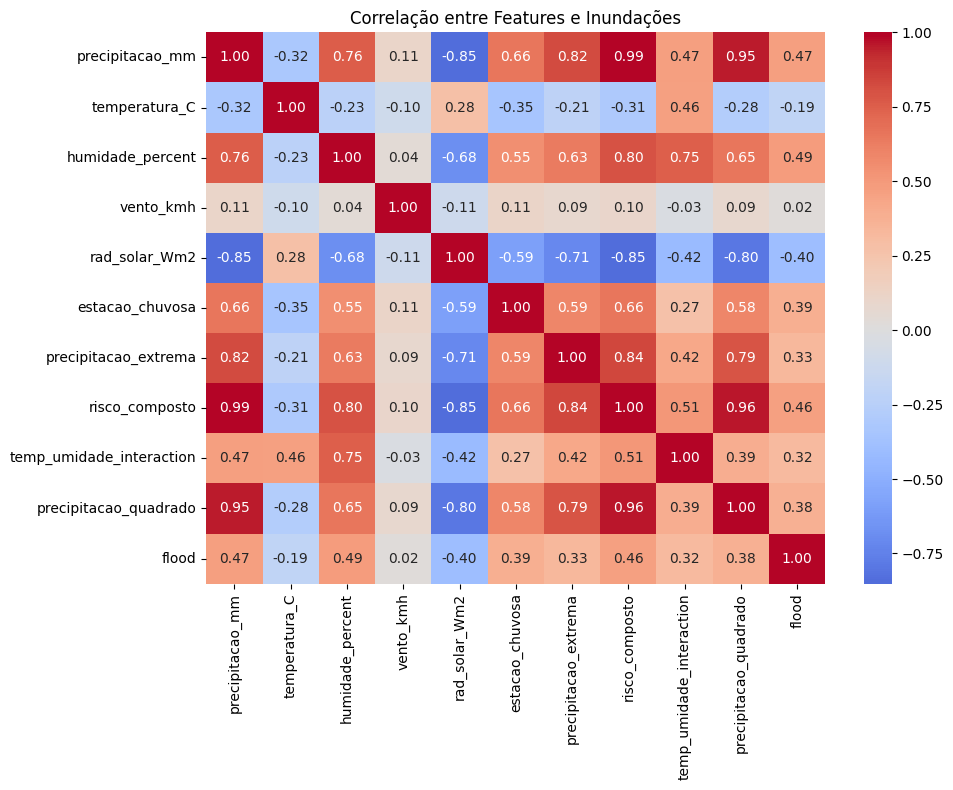


 MELHOR MODELO: Logistic Regression
 F1-Score: 0.8217
 Modelo salvo como: modelo_inundacoes_angola_20251112_160814.pkl



 SISTEMA CONCLUÍDO COM SUCESSO!


In [10]:
#@title 10. EXECUÇÃO NO COLAB
if __name__ == "__main__" and IN_COLAB:
    main_colab()
elif __name__ == "__main__":
    print(" Execute no Google Colab para funcionalidades completas")